In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
from openmmtools.integrators import LangevinIntegrator, LangevinSplittingGirsanov
import matplotlib

from deeptime.decomposition import TICA

import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn, optim, autograd
from torch.nn import functional as F
from torch.utils.data.dataset import random_split
from openmmtorch import TorchForce

from deeptime.clustering import MiniBatchKMeans
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.plots import plot_implied_timescales
from deeptime.util.validation import implied_timescales
from deeptime.markov import GirsanovReweightingEstimator

from scipy.linalg import eig
from scipy.stats import gaussian_kde
from pymbar import MBAR

import gc

from potential import *
from fmrc import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
def build_MSM(msm_lagtime,assignments):
    counts = TransitionCountEstimator(lagtime=msm_lagtime, count_mode='sliding').fit_fetch(assignments)
    msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

def Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=None):
    count_estimator = GirsanovReweightingEstimator(lagtime=msm_lagtime,count_mode='sliding')
    counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
    if stationary_pi is not None:
        msm = MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts)
    else:
        msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

# We need to further modify assignments_unbiased and assignments_biased
def reorganize_indices(assignments,n_microstates):
    populated_states = np.unique(assignments)
    empty_states = []
    assignments_new = np.zeros(assignments.shape,dtype=np.int32)
    shift = 0
    for idx in range(n_microstates):
        if idx in populated_states:
            idx_new = idx - shift
            assignments_new[np.where(assignments == idx)] = idx_new
        else:
            empty_states.append(idx)
            shift += 1
    return assignments_new, empty_states

def reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,align=None):
    eigenvectors_new = np.zeros((n_microstates,n_eigenvectors))
    shift = 0
    for idx in range(n_microstates):
        if idx in empty_states:
            shift += 1
            empty_entries = np.zeros(n_eigenvectors,)
            # Let values of eigenvectors being nan for plotting
            empty_entries[:] = np.nan
            eigenvectors_new[idx,:] = empty_entries
        else:
            idx_new = idx - shift
            pi_idx = msm.stationary_distribution[idx_new]
            ev_idx = msm.eigenvectors_right()[idx_new,1:n_eigenvectors]
            eigenvectors_new[idx,:] = np.concatenate([[pi_idx],ev_idx])
    if align is not None:
        # Align each eigenvector with the reference eigenvector
        for i in range(1,n_eigenvectors):
            if np.nansum(np.abs(-eigenvectors_new[:,i] - align[:,i])) < np.nansum(np.abs(eigenvectors_new[:,i] - align[:,i])):
                eigenvectors_new[:,i] = -eigenvectors_new[:,i]
    return eigenvectors_new

# We first compute the u_kn matrix
def us_bias(x,x0_k,k_spring):
    return 0.5 * k_spring * (x - x0_k)**2

def us_mbar_input(x,x0,k_spring,n_samples_per_window,unbiased=True,temp=310):
    kt = 8.314 * temp / 1000
    if unbiased == True:
        u_kn = np.zeros((len(x0)+1,len(x)))
        for k,x0_k in enumerate(x0):
            u_kn[k+1] = us_bias(x,x0_k,k_spring) / kt
        N_k = np.ones(n_windows+1,) * n_samples_per_window
        N_k[0] = 0
    else:
        u_kn = np.zeros((len(x0),len(x)))
        for k,x0_k in enumerate(x0):
            u_kn[k] = us_bias(x,x0_k,k_spring) / kt
        N_k = np.ones(n_windows,) * n_samples_per_window
    return u_kn,N_k

In [3]:
# matplotlib fonts
# matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 17.5

### 2d Muller Potential

In [4]:
# Load data
name = '2d_muller'
systemforce = MullerForce()

data_ref = np.load('traj_and_dat/{name}/unbiased_10x1000000.npy'.format(name=name))
n_repeats = 10

data_us = []
data_rerun = []
data_build_up = []
data_smd = []

for n_re in range(n_repeats):
    data_us.append(
        np.load('traj_and_dat/{name}/umbrella_sampling/50x2000_k=100_umbrella_sampling_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:,:500,:]
    )
    
    data_rerun.append(
        np.load('traj_and_dat/{name}/metad_rerun/100000_gamma=2_metad_rerun_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )
    
    data_build_up.append(
        np.load('traj_and_dat/{name}/metad_build_up/100000_gamma=2_metad_build_up_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )
    
    data_smd.append(
        np.load('traj_and_dat/{name}/steered_md/100000_v_pulling=0.0017_steered_md_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )

In [5]:
# TICA pre-processing
dim = None
var_cutoff = None
koopman = False
tica_lagtime = 1    # This is 1ps

# TICA pre-processing
tica,tica_output,tica_output_concat = run_TICA(data_ref[0],tica_lagtime,dim,var_cutoff,koopman)
data_input = [tica_output]
input_size = tica_output.shape[1]

fmrc = torch.load('models/muller_2d.pt')
# Transform into FMRC space
r = fmrc.transform(tica_output)

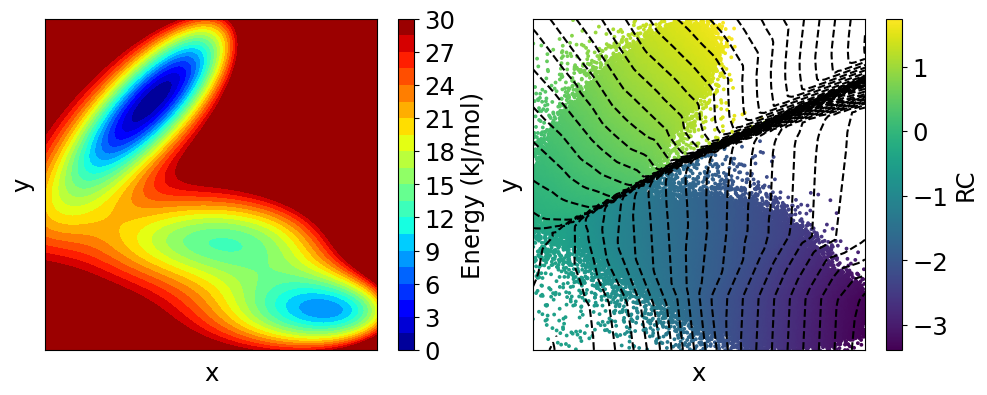

In [6]:
# Visualize
markersize = 3
stride = 1

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,4))

MullerForce.plot(ax=ax[0],fig=fig)

sc = ax[1].scatter(data_ref[0][:,0][::stride],data_ref[0][:,1][::stride],c=r[::stride],s=markersize)
plt.colorbar(sc,label='RC',ax=ax[1])
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_xlim([MullerForce().x_range[0],MullerForce().x_range[1]])
ax[1].set_ylim([MullerForce().y_range[0],MullerForce().y_range[1]])

# Visualize the whole sample space
x = np.linspace(MullerForce().x_range[0],MullerForce().x_range[1],100)
y = np.linspace(MullerForce().y_range[0],MullerForce().y_range[1],100)
X, Y = np.meshgrid(x,y)
# Flatten grid into (n_points, 2)
XY = np.column_stack([X.ravel(), Y.ravel()])
r_grid = fmrc.transform(tica.transform(XY)).reshape(X.shape)

contour = ax[1].contour(X, Y, r_grid, levels=50, colors='black',linestyles='--')
#plt.colorbar(contour, label='RC')
ax[0].set_xlabel('x',labelpad=8)
ax[0].set_ylabel('y',labelpad=8)
ax[1].set_xlabel('x',labelpad=8)
ax[1].set_ylabel('y',labelpad=8)
ax[0].tick_params(left=False,labelleft=False,bottom=False, labelbottom=False)
ax[1].tick_params(left=False,labelleft=False,bottom=False, labelbottom=False)
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/muller_and_rc.png'.format(name=name),dpi=600)
plt.show()

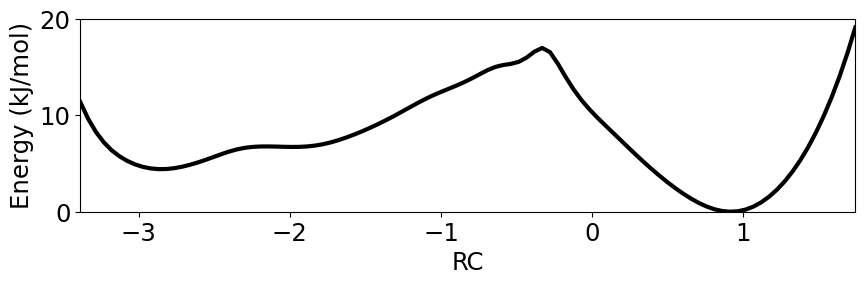

In [7]:
# Compute density estimation with weighted KDE
kde = gaussian_kde(np.concatenate(r),bw_method='silverman')
r_min = r.min()
r_max = r.max()
r_grid = np.linspace(r_min,r_max,100)

# Compute logpdf
logpdf = kde.logpdf(r_grid)
logpdf = logpdf - logpdf.max()
kt = 8.314 * 298.15/1000
energy = -kt * logpdf

fig,ax = plt.subplots(figsize=(10,2.5))
ax.plot(r_grid,energy,linewidth=3,color='black')
ax.set_ylim(0,20)
ax.set_xlim(r_min,r_max)
ax.set_xlabel('RC')
ax.set_ylabel('Energy (kJ/mol)')
plt.savefig('figures/{name}/energy.png'.format(name=name),dpi=600)

In [8]:
# Dimension Reduction
fmrc = torch.load('models/muller_2d.pt')

# TICA pre-processing
dim = None
var_cutoff = None
koopman = False
tica_lagtime = 1     # This is 1ps

# TICA pre-processing
tica = run_TICA(data_ref[0],tica_lagtime,dim,var_cutoff,koopman)[0]

data_ref_concat = np.concatenate(data_ref,axis=0)
tica_ref_concat = np.array(np.concatenate(tica.transform(data_ref),axis=0),dtype=np.float64)
r_ref_concat = fmrc.transform(tica_ref_concat)

In [9]:
# Grid Discretization
from deeptime.clustering import BoxDiscretization

# Construct grid box
dim = 1
n_boxes = 25
v0 = [-3.25]
v1 = [1.25]
#v0 = np.array([systemforce.x_range[0],systemforce.y_range[0]])
#v1 = np.array([systemforce.x_range[1],systemforce.y_range[1]])

grid_box = BoxDiscretization(
    dim=dim,  # the number of dimensions the data lives in
    n_boxes=n_boxes,  # number of boxes per axis (can also be single int for all axes)
    v0=v0,
    v1=v1
)

n_microstates = n_boxes**dim
microstates = grid_box.fit(r_ref_concat.reshape(-1,1)).fetch_model()
# Unbiased Reference
assignments_ref = microstates.transform(r_ref_concat.reshape(-1,1)).reshape(data_ref[:,:,0].shape)
assignments_ref,empty_states_ref = reorganize_indices(assignments_ref,n_microstates)

assignments_us = []
assignments_rerun = []
assignments_build_up = []
assignments_smd = []
r_us_concat = []

for n_re in range(n_repeats):
    # Umbrella Sampling
    r_us_concat_n = np.concatenate(data_us[n_re][:,:,2],axis=0)
    assignments_us_n = microstates.transform(r_us_concat_n.reshape(-1,1)).reshape(data_us[n_re][:,:,2].shape)
    assignments_us_n, empty_states_us_n = reorganize_indices(assignments_us_n,n_microstates)
    assignments_us.append((assignments_us_n, empty_states_us_n))
    
    # MetaD Rerun
    r_rerun_concat_n = data_rerun[n_re][:,2]
    assignments_rerun_n = microstates.transform(r_rerun_concat_n.reshape(-1,1)).reshape(data_rerun[n_re][:,2].shape)
    assignments_rerun_n, empty_states_rerun_n = reorganize_indices(assignments_rerun_n,n_microstates)
    assignments_rerun.append((assignments_rerun_n, empty_states_rerun_n))
    
    
    # MetaD Build-up
    r_build_up_concat_n = data_build_up[n_re][:,2]
    assignments_build_up_n = microstates.transform(r_build_up_concat_n.reshape(-1,1)).reshape(data_build_up[n_re][:,2].shape)
    assignments_build_up_n, empty_states_build_up_n = reorganize_indices(assignments_build_up_n,n_microstates)
    assignments_build_up.append((assignments_build_up_n, empty_states_build_up_n))
    
    # Steered MD
    r_smd_concat_n = data_smd[n_re][:,2]
    assignments_smd_n = microstates.transform(r_smd_concat_n.reshape(-1,1)).reshape(data_smd[n_re][:,2].shape)
    assignments_smd_n, empty_states_smd_n = reorganize_indices(assignments_smd_n,n_microstates)
    assignments_smd.append((assignments_smd_n, empty_states_smd_n))

#### 1. Short lag time $\tau = 1$

In [10]:
n_eigenvectors = 3               # Number of eigenvectors to compute, including the stationary vector

##### 1.1 Metadynamics Rerun

In [11]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,25,25),dtype=np.int32)
its = np.zeros((3,n_repeats,n_processes,len(its_lagtimes)))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_rerun[n_re]
    # ITS - Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_rerun[n_re][:,3],data_rerun[n_re][:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_rerun[n_re][:,3].shape),data_rerun[n_re][:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_rerun[n_re][:,3])
    stationary_pi = histogram / np.sum(histogram)
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

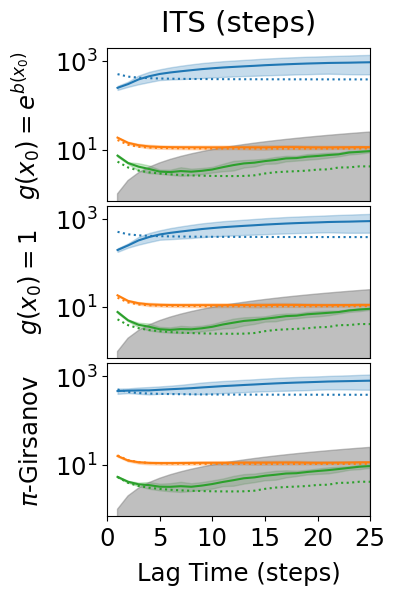

In [12]:
# Plot ITS
s = 15
ms = 5
nrows = 3
ncols = 1

labels = ['$g(x_0)=e^{b(x_0)}$','$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,6))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([0,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(0,its_lagtimes[-1],6))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[2].set_xlabel('Lag Time (steps)',labelpad=8)

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/rerun_its.png'.format(name=name),dpi=600)
plt.show()

In [49]:
# Reference MSM
msm_lagtime = 5
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((3, n_repeats, n_microstates, n_eigenvectors))
# Reference
eigenvectors_ref = reorganize_eigenvectors(msm_ref,n_eigenvectors,n_microstates,empty_states_ref)
eigenvectors_ref = eigenvectors_ref.reshape(n_microstates,-1)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_rerun[n_re]
    # Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_rerun[n_re][:,3],data_rerun[n_re][:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_rerun[n_re][:,2].shape),data_rerun[n_re][:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_rerun[n_re][:,3])
    stationary_pi = histogram / np.sum(histogram)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)

# 1D
ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)
# 2D
#eigenvectors_ref = eigenvectors_ref.reshape(n_boxes,n_boxes,-1)
#ev_mean = np.nanmean(ev,axis=1).reshape(3,n_boxes,n_boxes,-1)
#ev_std = np.nanstd(ev,axis=1).reshape(3,n_boxes,n_boxes,-1)

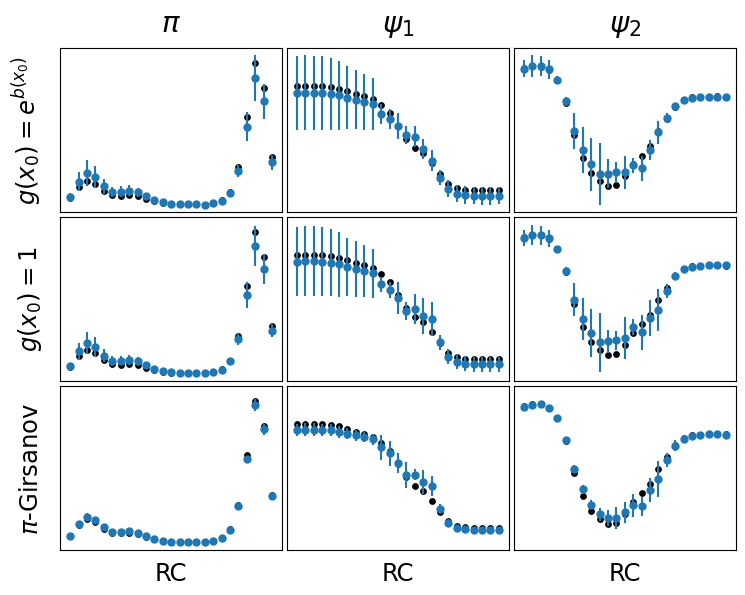

In [50]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 3
ncols = 3

labels = ['$g(x_0)=e^{b(x_0)}$','$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(7.5,6))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('RC',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/rerun_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.2 Metadynamics Build-up

In [51]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,25,25),dtype=np.int32)
its = np.zeros((4,n_repeats,n_processes,len(its_lagtimes)))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_build_up[n_re]
    # ITS - Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_build_up[n_re][:,3],data_build_up[n_re][:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_build_up[n_re][:,3].shape),data_build_up[n_re][:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_build_up[n_re][:,3])
    stationary_pi = histogram / np.sum(histogram)
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, optimize with the reference stationary constraint
    stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[3,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

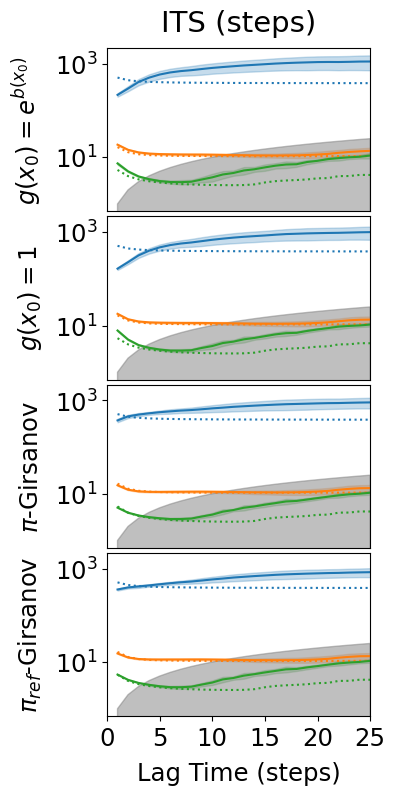

In [52]:
# Plot ITS
s = 15
ms = 5
nrows = 4
ncols = 1

labels = ['$g(x_0)=e^{b(x_0)}$','$g(x_0) =1$','$\pi$-Girsanov','$\pi_{ref}$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,8))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([0,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(0,its_lagtimes[-1],6))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[3].set_xlabel('Lag Time (steps)',labelpad=8)

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/build_up_its.png'.format(name=name),dpi=600)
plt.show()

In [53]:
# Reference MSM
msm_lagtime = 5
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((4, n_repeats, n_microstates, n_eigenvectors))
# Reference
eigenvectors_ref = reorganize_eigenvectors(msm_ref,n_eigenvectors,n_microstates,empty_states_ref)
eigenvectors_ref = eigenvectors_ref.reshape(n_microstates,-1)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_build_up[n_re]
    # Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_build_up[n_re][:,3],data_build_up[n_re][:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_build_up[n_re][:,3].shape),data_build_up[n_re][:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_build_up[n_re][:,3])
    stationary_pi = histogram / np.sum(histogram)
    #stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Use reference MSM stationary vector
    stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[3,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

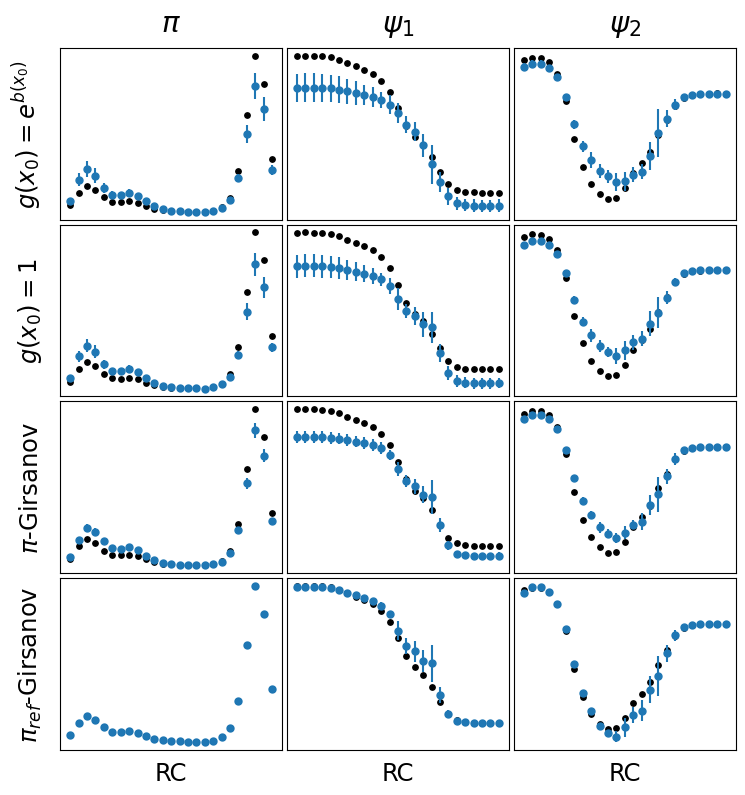

In [54]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 4
ncols = 3

labels = ['$g(x_0)=e^{b(x_0)}$','$g(x_0) =1$','$\pi$-Girsanov','$\pi_{ref}$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(7.5,8))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('RC',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
y_scales = []
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    y_scales.append(ax[idx,j].get_ylim())
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/build_up_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.3 Umbrella Sampling

In [55]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,10,10),dtype=np.int32)
its = np.zeros((4,n_repeats,n_processes,len(its_lagtimes)))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_us[n_re]
    # ITS - Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_us[n_re][:,:,3],data_us[n_re][:,:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_us[n_re][:,:,3].shape),data_us[n_re][:,:,4])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, optimize with the reference stationary constraint
    stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[3,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

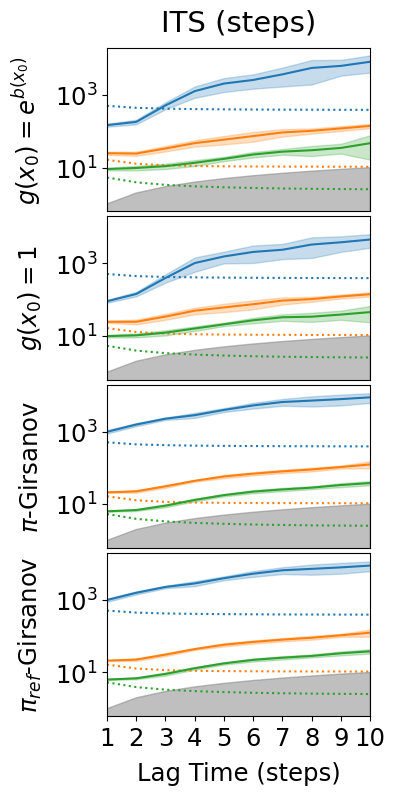

In [56]:
# Plot ITS
s = 15
ms = 5
nrows = 4
ncols = 1

labels = ['$g(x_0)=e^{b(x_0)}$','$g(x_0) =1$','$\pi$-Girsanov','$\pi_{ref}$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,8))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([1,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(1,its_lagtimes[-1],10))
    ax[i].set_yticks([10,1000])
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[3].set_xlabel('Lag Time (steps)',labelpad=8)       

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/us_its.png'.format(name=name),dpi=600)
plt.show()

In [57]:
# Reference MSM
msm_lagtime = 1
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((4, n_repeats, n_microstates, n_eigenvectors))
# Reference
eigenvectors_ref = reorganize_eigenvectors(msm_ref,n_eigenvectors,n_microstates,empty_states_ref)
eigenvectors_ref = eigenvectors_ref.reshape(n_microstates,-1)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_us[n_re]
    # Temporary fix for boundary states
    # Use MBAR factor for the path initial point as g factor
    reweighting_factors = (data_us[n_re][:,:,3],data_us[n_re][:,:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_us[n_re][:,:,3].shape),data_us[n_re][:,:,4])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    # Estimate a weighted histogram with MBAR weights
    histogram = np.bincount(np.concatenate(assignments_us[n_re][0]),weights=data_us[n_re][:,:,3].reshape(-1,))
    stationary_pi = histogram / np.sum(histogram)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Use reference MSM stationary vector
    stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[3,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    
ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

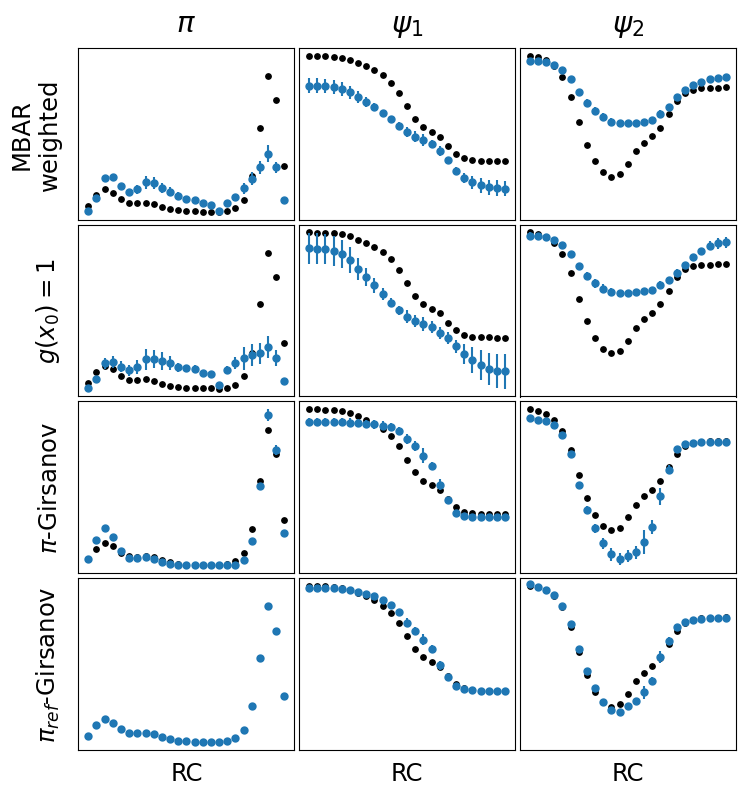

In [58]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 4
ncols = 3

labels = ['MBAR\nweighted','$g(x_0) =1$','$\pi$-Girsanov','$\pi_{ref}$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(7.5,8))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('RC',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
y_scales = []
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    y_scales.append(ax[idx,j].get_ylim())
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/us_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.4 Steered MD

In [59]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,10,10),dtype=np.int32)
its = np.zeros((2,n_repeats,n_processes,len(its_lagtimes)))
# For now we use ref stationary vector from the unbiased MSM, consider compute this with Jarzynski's equality
stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_smd[n_re]
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_smd[n_re][:,1].shape),data_smd[n_re][:,3])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

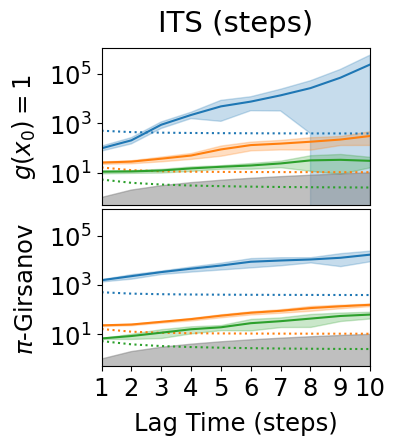

In [60]:
# Plot ITS
s = 15
ms = 5
nrows = 2
ncols = 1

labels = ['$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,4.5))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([1,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(1,its_lagtimes[-1],10))
    ax[i].set_yticks([10,1000,100000])
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[1].set_xlabel('Lag Time (steps)',labelpad=8)

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/smd_its.png'.format(name=name),dpi=600)
plt.show()

In [61]:
# Reference MSM
msm_lagtime = 1
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((2, n_repeats, n_microstates, n_eigenvectors))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_smd[n_re]
    # For now we use ref stationary vector from the unbiased MSM, consider compute this with Jarzynski's equality
    stationary_pi = np.delete(msm_ref.stationary_distribution,empty_states)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_smd[n_re][:,1].shape),data_smd[n_re][:,3])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,eigenvectors_ref)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

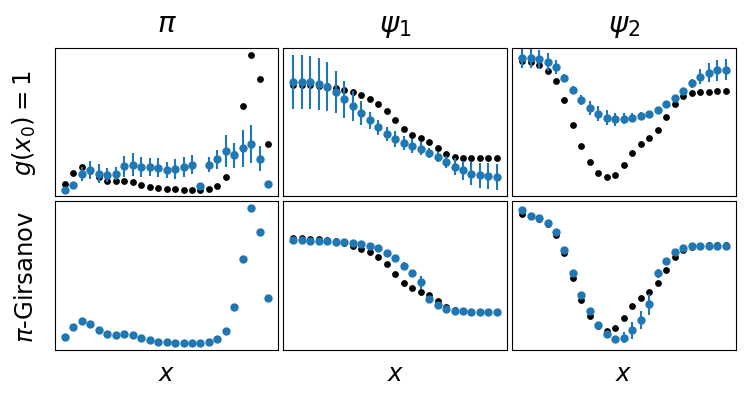

In [62]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 2
ncols = 3

labels = ['$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(7.5,4))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('$x$',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/smd_ev.png'.format(name=name),dpi=600)
plt.show()